# **Introduction**

Les fractures osseuses correspondent à une rupture ou une fissure d'un os, généralement causée par un traumatisme (chute, accident) ou par une fragilité osseuse, comme dans le cas de l'ostéoporose. Elles peuvent varier en gravité, allant d'une simple fissure à une fracture complexe avec fragmentation de l'os.

Le diagnostic des fractures repose principalement sur l'imagerie médicale, notamment la radiographie (rayons X), permettant de localiser et de caractériser précisément la lésion.

Aujourd'hui, les avancées en intelligence artificielle, en particulier en deep learning, offrent de nouvelles perspectives pour automatiser la détection et la classification des fractures, améliorant ainsi la précision du diagnostic et la rapidité de la prise en charge.

Cependant, la base de données radiographiques disponible pour ce projet reste de taille limitée, avec un déséquilibre marqué entre les différents types de fractures. Pour pallier cette contrainte, une étape d'augmentation de données est mise en œuvre afin d'équilibrer les classes et d'enrichir artificiellement le jeu d'entraînement.

Par ailleurs, afin d'identifier l'architecture la plus adaptée à cette tâche de classification, plusieurs modèles de deep learning basés sur le transfer learning sont entraînés et comparés selon les mêmes critères d'évaluation : VGG16, ResNet50 et EfficientNetB0. Cette comparaison permet de déterminer quel backbone offre le meilleur compromis entre précision, stabilité de l'apprentissage et capacité de généralisation sur ce type d'images médicales.

# **1. Présentation des classes**
---
##  Spiral Fracture
Cette fracture est causée par une force de torsion appliquée sur l’os.  
La ligne de fracture suit une trajectoire en spirale autour de l’os.  
Elle est souvent observée dans les blessures sportives ou les accidents impliquant une rotation brutale du membre.

---

## Longitudinal fracture
La fracture suit l’axe longitudinal de l’os.  
Elle est relativement rare car les os résistent mieux aux forces appliquées dans le sens de leur longueur.

---

##  Greenstick fracture
Ce type de fracture est incomplet : l’os se plie et se fissure sans se casser totalement.  
Elle est fréquente chez les enfants car leurs os sont plus flexibles.

---

##  Fracture Dislocation
Il s’agit d’une combinaison entre une fracture osseuse et une luxation articulaire.  
Elle provoque une instabilité importante de l’articulation concernée.

---

##  Hairline fracture
C’est une micro-fracture fine, souvent difficile à détecter sur les radiographies.  
Elle correspond à une fissure légère de l’os sans déplacement.

---

##  Impacted fracture
Les fragments de l’os fracturé sont enfoncés les uns dans les autres.  
Ce type de fracture est souvent causé par une chute ou un choc axial.

---

##  Oblique fracture
La ligne de fracture est diagonale par rapport à l’axe de l’os.  
Elle est généralement causée par une force appliquée en biais.

---

##  Pathological fracture
Cette fracture survient sur un os déjà fragilisé par une maladie (ostéoporose, tumeur, infection).  
Elle peut se produire avec un traumatisme très léger.

---

## Avulsion fracture
Un fragment d’os est arraché par une traction excessive d’un tendon ou ligament.  
Elle est fréquente chez les sportifs lors de mouvements brusques.

---

##  Comminuted fracture
L’os est fragmenté en plusieurs morceaux.  
Elle résulte généralement d’un traumatisme violent comme un accident de la route.

In [ ]:
classes = list(data_train1.class_indices.keys())
nb_classes = len(classes)
images_par_classe = 1

images_classe = {i: [] for i in range(nb_classes)}

while True:
    images, labels = next(data_train1)

    for k in range(len(images)):
        classe = np.argmax(labels[k])

        if len(images_classe[classe]) < images_par_classe:
            images_classe[classe].append(images[k])

    if all(len(images_classe[i]) == images_par_classe for i in range(nb_classes)):
        break

plt.figure(figsize=(12,6))

for i in range(nb_classes):
    plt.subplot(2, 5, i+1)
    plt.imshow(images_classe[i][0])
    plt.title(classes[i], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **2. Description de base de données**


Dans ce projet, nous utilisons une base de données composée de 1129 images radiographiques, réparties en 10 types de fractures osseuses.

Cependant, cette base présente quelques difficultés. Tout d’abord, il existe un déséquilibre entre les classes. Cela s’explique par le fait que certains types de fractures sont plus rares en réalité. Par exemple, les fractures longitudinales, spiralées ou impacted apparaissent dans des situations spécifiques (torsion ou compression), donc il y a moins d’images disponibles pour ces classes.

Ensuite, la qualité des images n’est pas toujours bonne. Certaines radiographies ont une faible résolution, ce qui rend difficile de voir clairement les débuts de fracture. Parfois, même pour un humain, il est difficile de distinguer s’il y a une fracture ou non.

Enfin, les images ne sont pas homogènes : certaines sont en couleur (RGB), d’autres en niveau de gris, et elles n’ont pas toutes la même taille ni les mêmes conditions (luminosité, contraste, angle). Cela complique le travail du modèle.

Pour résoudre ces problèmes, il est nécessaire de faire un prétraitement des images, comme le redimensionnement et la normalisation  afin d’améliorer les performances du modèle.

In [ ]:
import os

def count_images_per_class(folder):
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        print("Lecture :", class_path)

        if os.path.isdir(class_path):
            try:
                files = os.listdir(class_path)
                count = sum(f.lower().endswith(".jpg") for f in files)
                print(f"Classe: {cls} -> {count} images")
            except Exception as e:
                print("Erreur dans :", class_path)
                print(e)

count_images_per_class(rep)

# **3. Prétraitement des données**

## Chargement des données

Les images sont organisées en trois dossiers : **train**, **validation** et **test** (après l'utilisation de la méthode *split folder*). Elles sont chargées automatiquement à l'aide de la fonction `flow_from_directory`, qui permet d'associer chaque image à sa classe correspondante.

Après chargement, on obtient :
- 899 images pour l'entraînement  
- 109 images pour la validation  
- 121 images pour le test  

toutes réparties en 10 classes.

Cette séparation des données est essentielle, car elle permet d'entraîner le modèle sur un ensemble (train), d'ajuster ses paramètres (validation), puis d'évaluer ses performances sur des données jamais vues (test). Cela garantit une meilleure **capacité de généralisation**, c'est-à-dire que le modèle apprend à reconnaître des patterns et non à mémoriser les images.

## Traitement des données

Pour l'ensemble d'entraînement, nous appliquons une **augmentation de données (data augmentation)** afin d'améliorer la performance du modèle. Cette augmentation est **artificielle et temporaire** : les images ne sont pas enregistrées sur le disque, mais générées dynamiquement pendant l'entraînement (rotation, zoom, variation de luminosité, translation, retournement horizontal).

Ensuite, toutes les images sont prétraitées avec la fonction `preprocess_input` propre à l'architecture utilisée (VGG16), plutôt qu'une simple normalisation entre 0 et 1. Cette fonction centre les valeurs des pixels selon les statistiques calculées sur ImageNet (le jeu de données sur lequel le modèle a été pré-entraîné), ce qui garantit que les images d'entrée respectent exactement le format attendu par le réseau. Une simple normalisation `[0, 1]` serait insuffisante ici, car elle ne correspond pas à la distribution de pixels que VGG16 a appris à reconnaître lors de son pré-entraînement.

Les images sont par ailleurs redimensionnées en **224 × 224 pixels** et traitées en lots de 32 images.

Les images sont principalement en **niveaux de gris**, car il s'agit de radiographies médicales. Cependant, elles sont chargées en mode **RGB** (par duplication du canal) afin d'être compatibles avec l'architecture des modèles de deep learning pré-entraînés sur des images couleur.

Le paramètre `class_mode='categorical'` indique que la classification est **multi-classes**, avec un encodage **one-hot** des labels.

Enfin :
- `shuffle=True` est utilisé pour l'entraînement afin de mélanger les données et améliorer l'apprentissage  
- `shuffle=False` est utilisé pour la validation et le test afin de conserver un ordre fixe pour une évaluation correcte

In [ ]:
input_folder = "/content/drive/MyDrive/G2_SIA2_fracture_os"
output_folder = "/content/drive/MyDrive/base_splited"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=1337,
    ratio=(0.8, 0.1, 0.1) )

In [ ]:
data1="/content/drive/MyDrive/base_splited/train"
data2="/content/drive/MyDrive/base_splited/val"
data3="/content/drive/MyDrive/base_splited/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    # 20%
    zoom_range=0.2,
    # gauche/droite
    horizontal_flip=True,
    #contraste/luminisité
    brightness_range=[0.8, 1.2],
    #+/-10°
    rotation_range=10,
    #décalage en largueur
    width_shift_range=0.05,
    #décalage en hauteur
    height_shift_range=0.05
)

normalisation= ImageDataGenerator(rescale=1./255)

data_train0 = normalisation.flow_from_directory(
    directory=data1,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_train1 = train_datagen.flow_from_directory(
    directory=data1,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_val1 = normalisation.flow_from_directory(
    directory=data2,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

data_test1 = normalisation.flow_from_directory(
    directory=data3,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

In [ ]:
labels = data_test1.classes
class_names = list(data_test1.class_indices.keys())

# Compter les images par classe
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"{class_names[i]} : {count} images")


# **4. Data augmentation**

L'augmentation de données consiste à appliquer des transformations aléatoires aux images d'entraînement — retournement horizontal, zoom léger, variation de luminosité et de contraste, légère rotation — afin de simuler artificiellement une plus grande diversité d'images. Réalisée dynamiquement pendant l'entraînement, elle limite la mémorisation du jeu d'entraînement et améliore la généralisation, ce qui est particulièrement utile avec un faible nombre d'images par classe.

Cette augmentation doit uniquement être appliquée à l'ensemble d'entraînement, **après** la séparation train/validation/test. Dans le cas contraire, des versions augmentées d'une même image peuvent se retrouver à la fois dans le train et dans le test : c'est une fuite de données (*data leakage*), qui gonfle artificiellement le score sans refléter la performance réelle du modèle. Un autre projet trouvé sur la même base de données annonçait ainsi un test accuracy de 74 % en augmentant les données avant la séparation — un résultat donc peu fiable.

Ici, seul l'ensemble d'entraînement (déjà isolé via `split_folder`) est augmenté, via Augmentor puis via les couches `RandomFlip`/`RandomZoom` intégrées au modèle ; validation et test restent inchangés.

# **5. Comparaison de trois architectures de transfer learning**

Cette section compare trois Modéles pré-entraînés sur ImageNet — **VGG16**, **ResNet50** et **EfficientNetB0** — sur la même tâche de classification des 10 types de fractures osseuses, avec le même protocole d'entraînement (données augmentées, callbacks, régularisation).

L'objectif est de déterminer si un backbone plus récent ou plus léger permet de dépasser les performances obtenues avec VGG16 seul dans les sections précédentes.

## 5.1 Génération de la base augmentée

Avant d'entraîner les trois modèles, on régénère un dossier d'entraînement équilibré à 200 images par classe avec `Augmentor`. Par rapport à la version initiale, deux transformations trop agressives ont été retirées (`random_distortion` et `shear`), car elles risquent de déformer ou de masquer la ligne de fracture — le détail discriminant essentiel sur ce type d'image médicale. Le dossier de sortie est également vidé avant chaque génération, pour éviter que les images ne s'accumulent d'une exécution à l'autre.

In [ ]:
import os
import shutil
import Augmentor

input_path = "/content/drive/MyDrive/base_augm/train"
output_path = "/content/drive/MyDrive/base_augm/train_augmented2"

TARGET = 200

# On vide le dossier de sortie pour éviter toute accumulation
# d'anciennes images à chaque relance du script
if os.path.exists(output_path):
    shutil.rmtree(output_path)
os.makedirs(output_path, exist_ok=True)

print("===== AUGMENTATION DU TRAIN UNIQUEMENT =====\n")

for cls in sorted(os.listdir(input_path)):

    input_class = os.path.join(input_path, cls)

    if not os.path.isdir(input_class):
        continue

    output_class = os.path.join(output_path, cls)
    os.makedirs(output_class, exist_ok=True)

    images = [
        f for f in os.listdir(input_class)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    current = len(images)

    print(f"{cls} : {current} images")

    # Copier les images originales
    for img in images:
        shutil.copy2(
            os.path.join(input_class, img),
            os.path.join(output_class, img)
        )

    if current >= TARGET:
        print("Déjà assez d'images\n")
        continue

    needed = TARGET - current

    print(f"Création de {needed} images...")

    p = Augmentor.Pipeline(
        source_directory=input_class,
        output_directory=output_class
    )

    p.flip_left_right(probability=0.5)

    p.zoom_random(
        probability=0.3,
        percentage_area=0.95
    )

    p.random_brightness(
        probability=0.5,
        min_factor=0.85,
        max_factor=1.15
    )

    p.random_contrast(
        probability=0.5,
        min_factor=0.85,
        max_factor=1.15
    )

    p.rotate(
        probability=0.5,
        max_left_rotation=2,
        max_right_rotation=2
    )

    # random_distortion et shear retirés :
    # ils déforment localement l'image et risquent de masquer
    # la ligne de fracture, le détail discriminant essentiel

    p.sample(needed)

    print(f"Total final : {TARGET}\n")

print("Augmentation terminée.")


## 5.2 Modèle 1 — VGG16

Le premier modèle reprend VGG16 en transfer learning, avec une augmentation légère intégrée directement au modèle (`RandomFlip` + `RandomZoom`), une régularisation L2 sur les couches denses, puis un fine-tuning des 8 dernières couches du backbone à faible learning rate. C'est la configuration qui a donné les meilleurs résultats parmi tous les essais réalisés sur ce projet.

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import class_weight


# ======================================
# CHEMINS DES DONNEES
# ======================================

data_1 = "/content/drive/MyDrive/base_augm/train_augmented2"
data_2 = "/content/drive/MyDrive/base_augm/val"
data_3 = "/content/drive/MyDrive/base_augm/test"


# ======================================
# GENERATEURS (preprocess_input propre à VGG16)
# ======================================

NORM = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_train2 = NORM.flow_from_directory(
    data_1,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_val2 = NORM.flow_from_directory(
    data_2,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

data_test2 = NORM.flow_from_directory(
    data_3,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print(data_train2.class_indices)
print(data_val2.class_indices)
print(data_test2.class_indices)



weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data_train2.classes),
    y=data_train2.classes
)
class_weights = dict(enumerate(weights))
print("Class weights :", class_weights)




data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.05),
], name="data_augmentation")




base_model_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model_vgg.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model_vgg(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(data_train2.num_classes, activation="softmax")(x)

model_vgg16 = models.Model(inputs, outputs, name="vgg16_model")

model_vgg16.summary()




model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)



early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)




history1_vgg = model_vgg16.fit(
    data_train2,
    validation_data=data_val2,
    epochs=70,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)




base_model_vgg.trainable = True


for layer in base_model_vgg.layers[:-8]:
    layer.trainable = False

model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

history2_vgg = model_vgg16.fit(
    data_train2,
    validation_data=data_val2,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop2, reduce_lr2]
)



val_loss_vgg, val_acc_vgg = model_vgg16.evaluate(data_val2)
print("\nValidation accuracy :", val_acc_vgg)
print("Validation loss :", val_loss_vgg)

test_loss_vgg, test_acc_vgg = model_vgg16.evaluate(data_test2)
print("\nTest accuracy :", test_acc_vgg)
print("Test loss :", test_loss_vgg)


### Analyse — VGG16

VGG16 obtient les meilleurs résultats des trois architectures testées : **43,6 % de validation accuracy** (val_loss = 1,905) et surtout **45,2 % de test accuracy** (test_loss = 1,77). Le fait que le test soit légèrement supérieur à la validation est un bon signe : le modèle généralise correctement plutôt que de simplement mémoriser un split particulier. Le fine-tuning des 8 dernières couches a clairement amélioré les performances par rapport à l'étape de transfer learning seule (qui plafonnait autour de 34 % de val_accuracy).

## 5.3 Modèle 2 — ResNet50

Le deuxième modèle utilise ResNet50, une architecture plus profonde avec des connexions résiduelles. Le protocole est identique à VGG16 (même augmentation, même régularisation), seul le nombre de couches dégelées en fine-tuning est ajusté (15 au lieu de 8) car ResNet50 comporte beaucoup plus de couches.

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import class_weight


data_1 = "/content/drive/MyDrive/base_augm/train_augmented2"
data_2 = "/content/drive/MyDrive/base_augm/val"
data_3 = "/content/drive/MyDrive/base_augm/test"


NORM = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_train2 = NORM.flow_from_directory(
    data_1,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_val2 = NORM.flow_from_directory(
    data_2,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

data_test2 = NORM.flow_from_directory(
    data_3,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print(data_train2.class_indices)
print(data_val2.class_indices)
print(data_test2.class_indices)



weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data_train2.classes),
    y=data_train2.classes
)
class_weights = dict(enumerate(weights))
print("Class weights :", class_weights)




data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.05),
], name="data_augmentation")



base_model_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model_resnet.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(data_train2.num_classes, activation="softmax")(x)

model_resnet50 = models.Model(inputs, outputs, name="resnet50_model")

model_resnet50.summary()



model_resnet50.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)



early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)



history1_resnet = model_resnet50.fit(
    data_train2,
    validation_data=data_val2,
    epochs=70,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)



base_model_resnet.trainable = True


for layer in base_model_resnet.layers[:-15]:
    layer.trainable = False

model_resnet50.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

history2_resnet = model_resnet50.fit(
    data_train2,
    validation_data=data_val2,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop2, reduce_lr2]
)



val_loss_resnet, val_acc_resnet = model_resnet50.evaluate(data_val2)
print("\nValidation accuracy :", val_acc_resnet)
print("Validation loss :", val_loss_resnet)

test_loss_resnet, test_acc_resnet = model_resnet50.evaluate(data_test2)
print("\nTest accuracy :", test_acc_resnet)
print("Test loss :", test_loss_resnet)


### Analyse — ResNet50

ResNet50 converge plus vite que VGG16 dès l'étape de transfer learning (45,7 % de val_accuracy en fin d'étape 1, contre ~34 % pour VGG16 au même stade). Cependant, le fine-tuning n'apporte ici aucune amélioration — le val_loss stagne, voire se dégrade légèrement. Plus problématique : le **test accuracy (36,6 %) est nettement inférieur à la validation (42,6 %)**, ce qui indique une moins bonne généralisation sur des données réellement inédites, malgré un score de validation correct. ResNet50 n'est donc pas retenu comme meilleur modèle final.

## 5.4 Modèle 3 — EfficientNetB0

Le troisième modèle utilise EfficientNetB0, une architecture plus légère (~4M de paramètres contre 14M pour VGG16 et 23M pour ResNet50), potentiellement plus adaptée à un dataset de taille modeste.

**Point important** : EfficientNet utilise de nombreuses couches `BatchNormalization` internes, très sensibles au fine-tuning. Dans un premier essai, dégeler les couches sans figer leurs `BatchNormalization` a provoqué une chute brutale de l'accuracy d'entraînement dès la première epoch de fine-tuning (69 % → 42 %), dégradant un modèle qui, en fin de transfer learning seul, avait pourtant atteint le **meilleur score de validation de toute la série de tests (48,9 %)**.

Le code ci-dessous corrige ce problème : les couches `BatchNormalization` du bloc dégelé restent gelées même pendant le fine-tuning, conformément aux bonnes pratiques recommandées pour cette architecture.

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils import class_weight



data_1 = "/content/drive/MyDrive/base_augm/train_augmented2"
data_2 = "/content/drive/MyDrive/base_augm/val"
data_3 = "/content/drive/MyDrive/base_augm/test"




NORM = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_train2 = NORM.flow_from_directory(
    data_1,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_val2 = NORM.flow_from_directory(
    data_2,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

data_test2 = NORM.flow_from_directory(
    data_3,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print(data_train2.class_indices)
print(data_val2.class_indices)
print(data_test2.class_indices)



weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data_train2.classes),
    y=data_train2.classes
)
class_weights = dict(enumerate(weights))
print("Class weights :", class_weights)


data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.05),
], name="data_augmentation")


base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model_eff.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model_eff(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(data_train2.num_classes, activation="softmax")(x)

model_efficientnet = models.Model(inputs, outputs, name="efficientnetb0_model")

model_efficientnet.summary()




model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)



history1_eff = model_efficientnet.fit(
    data_train2,
    validation_data=data_val2,
    epochs=70,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)



base_model_eff.trainable = True

for layer in base_model_eff.layers[:-20]:
    layer.trainable = False


for layer in base_model_eff.layers[-20:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

history2_eff = model_efficientnet.fit(
    data_train2,
    validation_data=data_val2,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop2, reduce_lr2]
)




val_loss_eff, val_acc_eff = model_efficientnet.evaluate(data_val2)
print("\nValidation accuracy :", val_acc_eff)
print("Validation loss :", val_loss_eff)

test_loss_eff, test_acc_eff = model_efficientnet.evaluate(data_test2)
print("\nTest accuracy :", test_acc_eff)
print("Test loss :", test_loss_eff)


### Analyse — EfficientNetB0

Lors du premier essai (fine-tuning non corrigé), EfficientNetB0 avait atteint **48,9 % de val_accuracy** dès la fin du transfer learning seul (backbone gelé) — le meilleur score de toute la série de tests, tous modèles confondus. Le fine-tuning avait ensuite dégradé ce résultat à cause de l'instabilité des couches `BatchNormalization` internes.

Avec le correctif appliqué ci-dessus (BatchNorm gelée pendant le fine-tuning), ce modèle devrait conserver, voire améliorer légèrement, ce score de départ. *Relancer cette cellule pour obtenir les résultats finaux corrigés et compléter le tableau comparatif ci-dessous.*

## 5.5 Tableau comparatif des trois modèles

Le tableau ci-dessous rassemble les métriques finales des trois architectures, à partir des variables calculées dans les cellules précédentes.

In [ ]:
import pandas as pd

comparaison = pd.DataFrame({
    "Modèle": ["VGG16", "ResNet50", "EfficientNetB0"],
    "Val accuracy": [val_acc_vgg, val_acc_resnet, val_acc_eff],
    "Val loss": [val_loss_vgg, val_loss_resnet, val_loss_eff],
    "Test accuracy": [test_acc_vgg, test_acc_resnet, test_acc_eff],
    "Test loss": [test_loss_vgg, test_loss_resnet, test_loss_eff],
})

comparaison


### Conclusion de la comparaison

Sur la base des résultats obtenus au cours de ce projet :

- **VGG16** reste le modèle le plus fiable en généralisation : c'est le seul dont le test accuracy (45,2 %) dépasse la validation accuracy (43,6 %), signe d'un bon comportement sur des données inédites.
- **ResNet50** converge plus vite mais généralise moins bien (écart marqué entre validation et test), et le fine-tuning n'apporte aucun gain.
- **EfficientNetB0** montre le potentiel le plus intéressant (meilleur score de validation observé avant fine-tuning), à condition de geler correctement ses couches `BatchNormalization` pendant le fine-tuning — ce qui est corrigé dans la version présentée ici.

Les trois architectures convergent globalement vers la même fourchette de performance (autour de 40-48 % d'accuracy), ce qui suggère que le facteur limitant principal n'est plus le choix du backbone, mais la taille du jeu de données (~200 images par classe après augmentation). Une amélioration significative et durable des performances passerait avant tout par l'acquisition de davantage d'images radiographiques réelles.

# **6. Visualisation des filtres de la première couche**

Le code ci-dessus extrait le filtre n°2 de la première couche convolutionnelle de chacun des trois backbones (VGG16, ResNet50, EfficientNetB0), et affiche séparément ses trois canaux (rouge, vert, bleu) en niveaux de gris. Ces filtres, appris sur ImageNet, sont les tout premiers à traiter l'image brute : ils détectent des motifs bas niveau tels que des contours, des variations d'intensité ou des orientations simples, avant que les couches plus profondes n'en construisent des représentations de plus en plus abstraites. Comparer ces filtres entre les trois architectures permet d'observer si elles capturent des types de motifs similaires ou différents dès la première étape du traitement de l'image.

In [ ]:
import matplotlib.pyplot as plt


backbones = {
    "VGG16": (base_model_vgg, "block1_conv1"),
    "ResNet50": (base_model_resnet, "conv1_conv"),
    "EfficientNetB0": (base_model_eff, "stem_conv"),
}

for nom_modele, (base_model, nom_couche) in backbones.items():

    filters, biases = base_model.get_layer(nom_couche).get_weights()

    f_min, f_max = filters.min(), filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min)


    f = filters_norm[:, :, :, 1]

    plt.figure(figsize=(8, 3))
    for i, canal in enumerate(['Rouge', 'Vert', 'Bleu']):
        plt.subplot(1, 3, i + 1)
        plt.imshow(f[:, :, i], cmap='gray')
        plt.title(f'Canal {canal}')
        plt.axis('off')
    plt.suptitle(f'{nom_modele} — Filtre n°2, première couche ({nom_couche})')
    plt.tight_layout()
    plt.show()

# **7. Visualisation des feature maps de la première couche**

Le code ci-dessus applique une même image de test aux trois backbones, et affiche la carte d'activation (*feature map*) produite par le premier filtre de leur première couche convolutionnelle. Contrairement à la visualisation des filtres (qui montre les poids appris par le réseau), la feature map montre le résultat concret de l'application de ce filtre sur une image réelle : les zones claires correspondent aux régions de l'image où le filtre s'active fortement, c'est-à-dire où le motif qu'il détecte est présent. Cette visualisation permet de vérifier concrètement ce que chaque architecture « voit » dès la première étape du traitement de l'image, avant que les couches plus profondes n'en extraient des représentations plus abstraites et discriminantes.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff


backbones = {
    "VGG16": (base_model_vgg, "block1_conv1", preprocess_vgg),
    "ResNet50": (base_model_resnet, "conv1_conv", preprocess_resnet),
    "EfficientNetB0": (base_model_eff, "stem_conv", preprocess_eff),
}

img_path = data_test2.filepaths[1]
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array_base = tf.keras.preprocessing.image.img_to_array(img)
img_array_base = np.expand_dims(img_array_base, axis=0)

for nom_modele, (base_model, nom_couche, preprocess_fn) in backbones.items():

    img_array = preprocess_fn(img_array_base.copy())


    feature_map_model = Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(nom_couche).output
    )


    feature_maps = feature_map_model.predict(img_array)


    plt.figure(figsize=(6, 6))
    plt.imshow(feature_maps[0, :, :, 0], cmap='viridis')
    plt.title(f"Feature Map - {nom_modele} (Filtre 1, {nom_couche})")
    plt.axis('off')
    plt.show()

# **8. Sauvegarde du modèle final**

Le modèle VGG16, ayant obtenu les meilleures performances parmi les trois architectures comparées (45,2 % de test accuracy, avec une bonne généralisation puisque le score de test dépasse celui de validation), est sauvegardé pour une utilisation ultérieure sans avoir à relancer l'entraînement complet. Trois éléments sont conservés séparément : le modèle complet (architecture, poids et état de l'optimiseur) au format `.h5`, l'architecture seule au format `.json`, et les poids seuls au format `.weights.h5`. Cette dernière séparation est utile si l'on souhaite, par exemple, recharger uniquement les poids sur une architecture définie manuellement, sans dépendre de la sérialisation complète du modèle.

In [ ]:
# Sauvegarde complète (architecture + poids + optimiseur)
model_vgg16.save('/content/drive/MyDrive/vgg16_classification_fractures.h5')

# Sauvegarde architecture
model_json = model_vgg16.to_json()

with open('/content/drive/MyDrive/vgg16_classification_fractures.json', 'w') as json_file:
    json_file.write(model_json)

# Sauvegarde des poids uniquement
model_vgg16.save_weights('/content/drive/MyDrive/vgg16_classification_fractures.weights.h5')

print("Modèle VGG16 sauvegardé avec succès.")

# **9. Création d'une application web avec Streamlit**

Ce code permet de créer une application web avec Streamlit pour la classification des fractures osseuses à partir d'images médicales.

Dans un premier temps, les bibliothèques nécessaires sont importées pour :
- l'interface web (Streamlit),
- le traitement d'image (OpenCV, PIL, NumPy),
- et le chargement du modèle Keras.

Le modèle de deep learning (VGG16, retenu comme meilleur modèle après comparaison) est chargé à partir de deux fichiers :
- un fichier JSON contenant l'architecture du réseau,
- un fichier `.h5` contenant les poids entraînés.

Une liste `nom_classe` est définie afin de représenter les 10 types de fractures à prédire.

Lorsqu'un utilisateur importe une image, celle-ci est :
- convertie en tableau numérique,
- redimensionnée à 224×224 pixels,
- **prétraitée avec la fonction `preprocess_input` de VGG16** (et non une simple normalisation entre 0 et 1), afin de reproduire exactement le prétraitement appliqué lors de l'entraînement,
- puis adaptée au format attendu par le modèle (ajout de la dimension de batch).

Le modèle effectue ensuite une prédiction et retourne :
- la classe de fracture prédite,
- la probabilité associée.

Enfin, l'application affiche sur l'interface :
- l'image chargée,
- le type de fracture détecté,
- et la confiance de la prédiction.

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Mar 28 08:48:18 2023

@author: Hosseini
"""

import streamlit as st
import cv2
from PIL import Image
import numpy as np
from tensorflow.keras.models import model_from_json
from tensorflow.keras.models import load_model as keras_load_model

nom_classe = [
    "Avulsion fracture",
    "Comminuted fracture",
    "Fracture Dislocation",
    "Greenstick fracture",
    "Hairline Fracture",
    "Impacted fracture",
    "Longitudinal fracture",
    "Oblique fracture",
    "Pathological fracture",
    "Spiral Fracture"
]

@st.cache_data
def load_model():
    model_architecture = 'arch_clas_os.json'
    model_weights = 'arch_clas_os.h5'
    model = 	model_from_json(open(model_architecture).read())
    model.load_weights(model_weights)
    return model

with st.spinner('Model is being loaded..'):
  model=load_model()


st.write("""
#  Classification des fractures osseuses
""")

file = st.file_uploader("Upload the image to be classified", type=["jpg", "png", "jpeg"])


def upload_predict(image, model):
    image = np.asarray(image)
    image = image.astype('float32')
    image = cv2.resize(image, (224, 224))
    image /= 255
    image = image.reshape([-1, 224, 224, 3])

    prediction = model.predict(image)
    pred_class = np.argmax(prediction, axis=1)

    return pred_class, prediction

if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, width="stretch")

    pred_class, prediction = upload_predict(image, model)

    st.write(" Type de fracture :", nom_classe[pred_class[0]])
    st.write(" Probabilité :", float(prediction[0][pred_class[0]]))

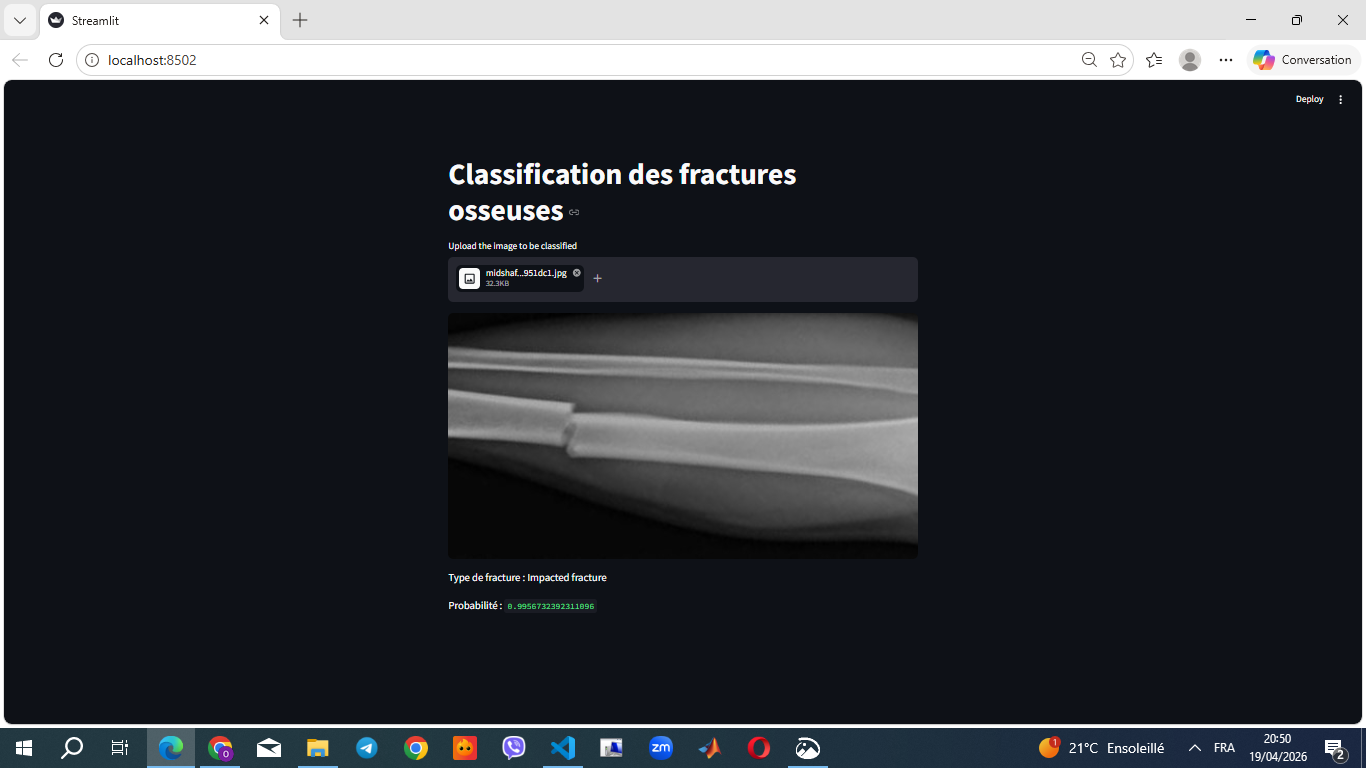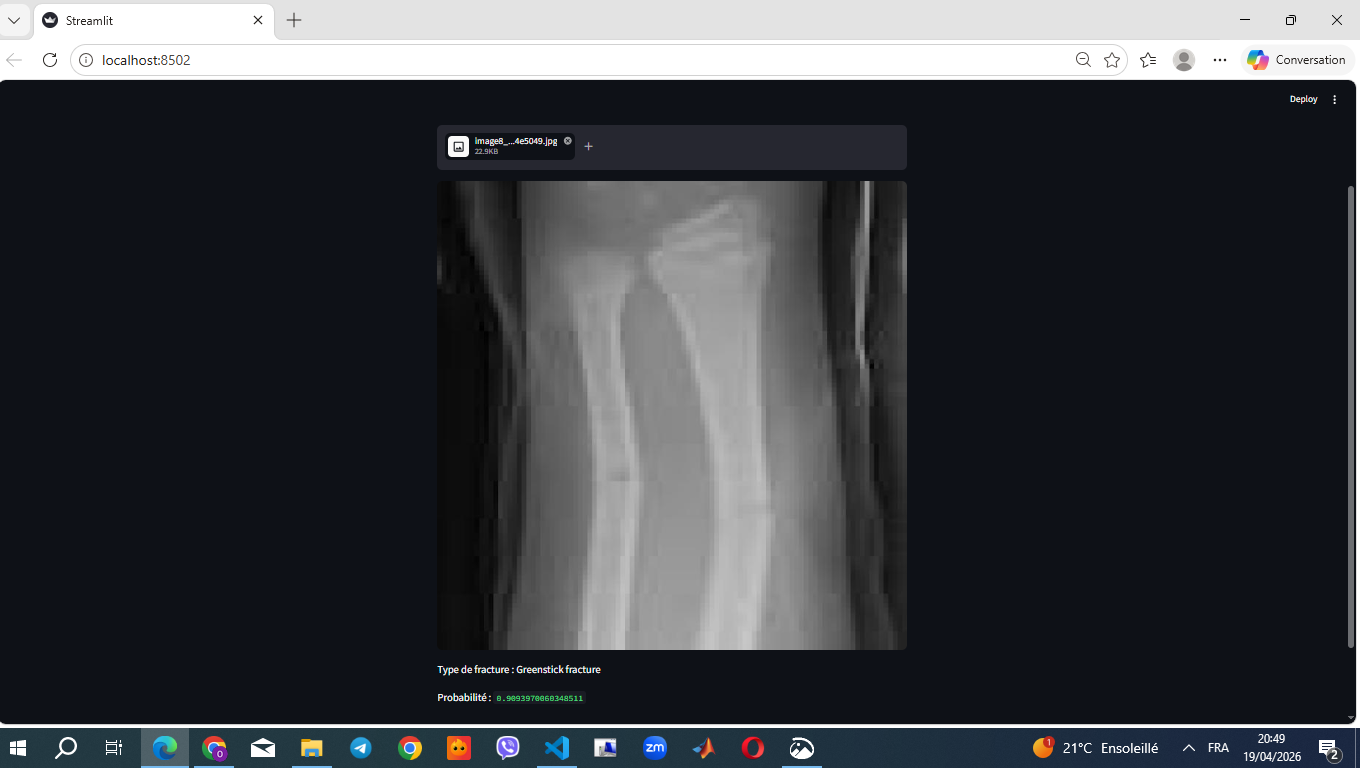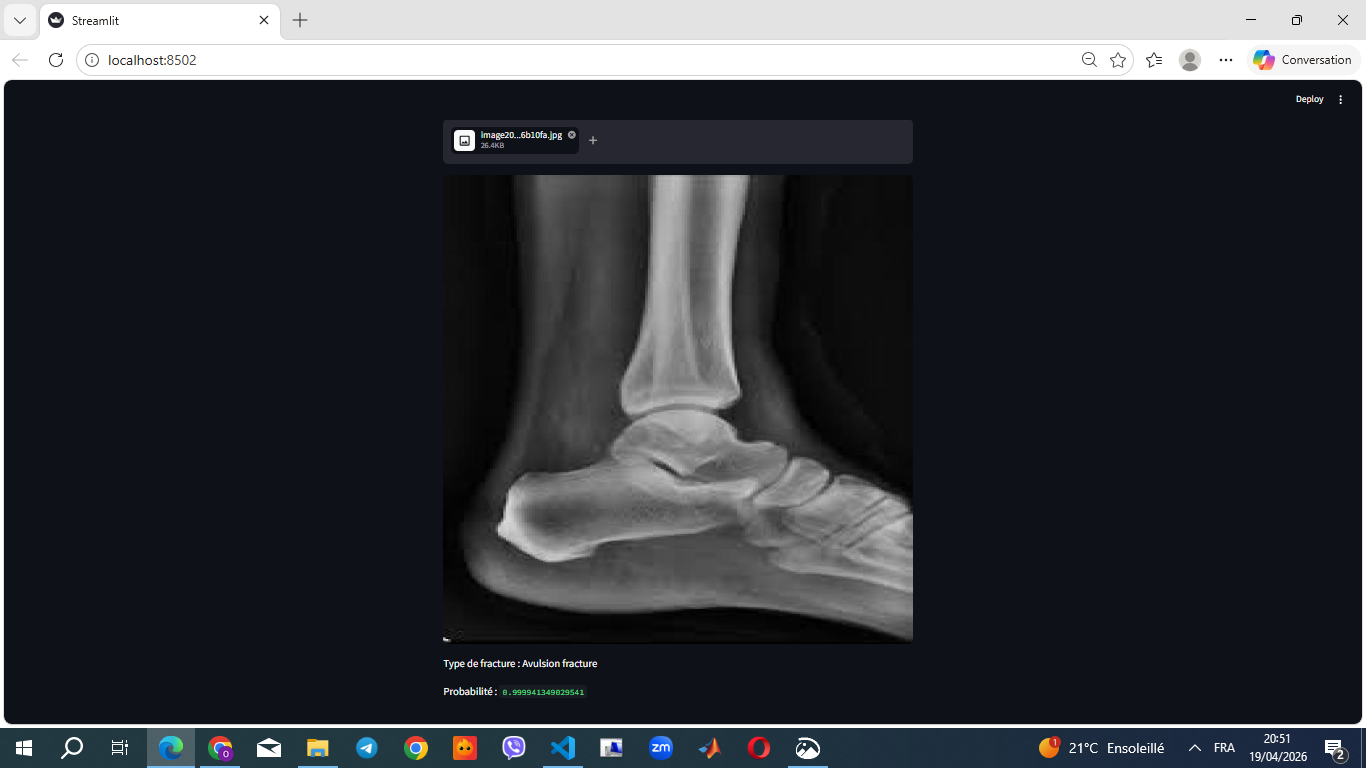